<a href="https://colab.research.google.com/github/EfeKaanCaglayan/ce477-nasdaq-macro/blob/main/nasdaq_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CE 477 – Nasdaq ve Makroekonomik Faktörler: Veri Seti Oluşturma

Bu notebook şunları yapar:
1. FRED'den makroekonomik serileri, Yahoo Finance'ten borsa endekslerini çeker
2. Günlük ve aylık verileri **aylık** tek bir tabloda birleştirir
3. Türetilmiş özellikler ekler (getiri, oynaklık, enflasyon, faiz değişimi…)
4. Veri setini `data/` klasörüne CSV olarak kaydeder
5. Rapordaki **Data Set Description** bölümü için istatistikleri ve grafikleri üretir (`figures/`)

Çalıştırmak için: **Çalışma zamanı → Tümünü çalıştır**

## 1. Kurulum

In [1]:
!pip install -q yfinance

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

START = "1990-01-01"          # VIX 1990'da başladığı için ortak başlangıç
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 2. FRED'den makroekonomik veriler

FRED'in herkese açık CSV adresi kullanılıyor, API anahtarı gerekmiyor.

In [2]:
FRED_SERIES = {
    "PAYEMS":     "nonfarm_payrolls",   # Tarım dışı istihdam (bin kişi), aylık
    "UNRATE":     "unemployment_rate",  # İşsizlik oranı (%), aylık
    "FEDFUNDS":   "fed_funds_rate",     # Fed faiz oranı (%), aylık
    "CPIAUCSL":   "cpi",                # Tüketici fiyat endeksi, aylık
    "DGS10":      "treasury_10y",       # 10 yıllık tahvil faizi (%), günlük
    "VIXCLS":     "vix",                # Korku endeksi, günlük
    "DCOILWTICO": "oil_wti",            # WTI petrol fiyatı ($/varil), günlük
}

def fetch_fred(code):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={code}"
    s = pd.read_csv(url, index_col=0, parse_dates=True, na_values=".").iloc[:, 0]
    return pd.to_numeric(s, errors="coerce").rename(code)

fred_raw = {}
for code in FRED_SERIES:
    fred_raw[code] = fetch_fred(code)
    s = fred_raw[code].dropna()
    print(f"{code:11s} {len(s):6d} gözlem  {s.index.min().date()} → {s.index.max().date()}")

PAYEMS        1053 gözlem  1939-01-01 → 2026-09-01
UNRATE         944 gözlem  1948-01-01 → 2026-09-01
FEDFUNDS       867 gözlem  1954-07-01 → 2026-09-01
CPIAUCSL       955 gözlem  1947-01-01 → 2026-08-01
DGS10        16173 gözlem  1962-01-02 → 2026-10-01
VIXCLS        9286 gözlem  1990-01-02 → 2026-10-01
DCOILWTICO    9512 gözlem  1986-01-02 → 2026-09-29


## 3. Yahoo Finance'ten borsa endeksleri

Nasdaq Composite (`^IXIC`) hedef değişken. S&P 500 ve BIST 100 karşılaştırma için.

In [3]:
TICKERS = {"^IXIC": "nasdaq", "^GSPC": "sp500", "XU100.IS": "bist100"}

prices = yf.download(list(TICKERS), start=START, auto_adjust=True, progress=False)["Close"]
prices = prices.rename(columns=TICKERS)

# Yahoo yanıt vermezse Nasdaq için FRED yedeği
if "nasdaq" not in prices or prices["nasdaq"].dropna().empty:
    print("Yahoo'dan Nasdaq gelmedi, FRED NASDAQCOM kullanılıyor")
    prices["nasdaq"] = fetch_fred("NASDAQCOM")

for col in prices.columns:
    s = prices[col].dropna()
    print(f"{col:8s} {len(s):6d} gün  {s.index.min().date()} → {s.index.max().date()}")

bist100    7308 gün  1997-07-01 → 2026-10-05
sp500      9256 gün  1990-01-02 → 2026-10-02
nasdaq     9256 gün  1990-01-02 → 2026-10-02


Ham günlük verileri de saklıyoruz (tekrar üretilebilirlik için):

In [4]:
daily = pd.concat([prices] + [fred_raw[c].rename(FRED_SERIES[c])
                              for c in ["DGS10", "VIXCLS", "DCOILWTICO"]], axis=1)
daily = daily.loc[START:].sort_index()
daily.index.name = "date"
daily.to_csv("data/raw_daily.csv")
daily.tail()

,bist100,sp500,nasdaq,treasury_10y,vix,oil_wti
date,,,,,,
2026-09-29,12290.599609,7670.839844,26797.539062,5.26,16.04,96.16
2026-09-30,11947.200195,7651.540039,26861.060547,5.29,16.34,NaN
2026-10-01,12249.000000,7666.450195,26871.599609,5.24,16.39,NaN
2026-10-02,12270.200195,7722.720215,27190.859375,NaN,NaN,NaN
2026-10-05,12410.830078,NaN,NaN,NaN,NaN,NaN


## 4. Aylık tabloya dönüştürme

- Endeksler: ayın **son** işlem günü kapanışı
- Günlük faiz, VIX ve petrol: ayın **ortalaması**
- Aylık seriler (istihdam, işsizlik, faiz, TÜFE): olduğu gibi, ay sonuna hizalanır
- Nasdaq oynaklığı: o aydaki günlük getirilerin standart sapması

In [5]:
ME = "ME"  # ay sonu (eski pandas sürümlerinde "M")
try:
    pd.Series([1], index=pd.to_datetime(["2020-01-31"])).resample(ME).last()
except ValueError:
    ME = "M"

monthly_prices = prices.resample(ME).last()

daily_fred = pd.concat([fred_raw[c].rename(FRED_SERIES[c])
                        for c in ["DGS10", "VIXCLS", "DCOILWTICO"]], axis=1)
monthly_daily_fred = daily_fred.resample(ME).mean()

monthly_fred = pd.concat([fred_raw[c].rename(FRED_SERIES[c])
                          for c in ["PAYEMS", "UNRATE", "FEDFUNDS", "CPIAUCSL"]], axis=1)
monthly_fred = monthly_fred.resample(ME).last()

nasdaq_vol = prices["nasdaq"].pct_change().resample(ME).std() * np.sqrt(21) * 100
nasdaq_vol = nasdaq_vol.rename("nasdaq_volatility")

df = pd.concat([monthly_prices, monthly_fred, monthly_daily_fred, nasdaq_vol], axis=1)
df = df.loc[START:]
df.index.name = "date"
df.tail()

/tmp/ipykernel_1392/4043129561.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  nasdaq_vol = prices["nasdaq"].pct_change().resample(ME).std() * np.sqrt(21) * 100


,bist100,sp500,nasdaq,nonfarm_payrolls,unemployment_rate,fed_funds_rate,cpi,treasury_10y,vix,oil_wti,nasdaq_volatility
date,,,,,,,,,,,
2026-06-30,14121.799805,7499.359863,26213.720703,158892.0,4.2,3.63,332.568,4.470476,17.906818,84.807143,7.760846
2026-07-31,13458.099609,7489.720215,25373.849609,158882.0,4.1,3.63,332.813,4.599545,17.090870,80.456364,5.499783
2026-08-31,14334.099609,7686.140137,26370.890625,159015.0,4.1,3.63,334.131,4.684286,15.229524,83.897619,4.722603
2026-09-30,11947.200195,7651.540039,26861.060547,159044.0,4.2,3.75,NaN,4.989048,15.775455,97.314500,4.082495
2026-10-31,12410.830078,7722.720215,27190.859375,NaN,NaN,NaN,NaN,5.240000,16.390000,NaN,3.092804


## 5. Türetilmiş özellikler

| Sütun | Açıklama |
| --- | --- |
| `nasdaq_return`, `sp500_return`, `bist100_return` | Aylık getiri (%) |
| `nasdaq_up` | Nasdaq bu ay yükseldi mi? (1/0) – sınıflandırma hedefi |
| `inflation_yoy` | Yıllık enflasyon (%), TÜFE'den |
| `payrolls_change` | Aylık istihdam değişimi (bin kişi) |
| `fed_funds_change`, `treasury_10y_change` | Faizlerdeki aylık değişim (puan) |
| `oil_return` | Petrol fiyatı aylık değişimi (%) |
| `term_spread` | 10 yıllık faiz − Fed faizi (puan) |
| `real_rate` | Fed faizi − yıllık enflasyon (puan) |
| `nasdaq_drawdown` | Nasdaq'ın o ana kadarki zirvesinden uzaklığı (%) |

In [6]:
df["nasdaq_return"]  = df["nasdaq"].pct_change(fill_method=None) * 100
df["sp500_return"]   = df["sp500"].pct_change(fill_method=None) * 100
df["bist100_return"] = df["bist100"].pct_change(fill_method=None) * 100
df["nasdaq_up"]      = (df["nasdaq_return"] > 0).astype("Int64").where(df["nasdaq_return"].notna())

df["inflation_yoy"]        = df["cpi"].pct_change(12, fill_method=None) * 100
df["payrolls_change"]      = df["nonfarm_payrolls"].diff()
df["fed_funds_change"]     = df["fed_funds_rate"].diff()
df["treasury_10y_change"]  = df["treasury_10y"].diff()
df["oil_return"]           = df["oil_wti"].pct_change(fill_method=None) * 100
df["term_spread"]          = df["treasury_10y"] - df["fed_funds_rate"]
df["real_rate"]            = df["fed_funds_rate"] - df["inflation_yoy"]
df["nasdaq_drawdown"]      = (df["nasdaq"] / df["nasdaq"].cummax() - 1) * 100

# İlk ay getiri hesaplanamadığı için boş; analiz dönemini 1991'den başlatıyoruz
df = df.loc["1991-01-01":]
print(df.shape)

(430, 23)


## 6. Eksik değerler ve son tablo

BIST 100 Yahoo'da daha geç başladığı ve bazı aylarda boşluk olduğu için **opsiyonel** sütun olarak bırakılıyor;
ana analiz için diğer sütunlarda eksik olmayan aylar kullanılıyor.
Son ayın aylık verileri (istihdam, TÜFE) henüz açıklanmamış olabilir, bu satır da düşürülüyor.

In [7]:
missing = df.isna().sum().to_frame("missing").assign(
    missing_pct=lambda t: (t["missing"] / len(df) * 100).round(1))
display(missing[missing["missing"] > 0])

core_cols = [c for c in df.columns if not c.startswith("bist100")]
dataset = df.dropna(subset=core_cols)
print(f"Ham aylık tablo: {df.shape}  →  Temiz veri seti: {dataset.shape}")
print(f"Dönem: {dataset.index.min():%Y-%m} → {dataset.index.max():%Y-%m}")

dataset.to_csv("data/nasdaq_macro_monthly.csv", float_format="%.4f")
print("Kaydedildi: data/nasdaq_macro_monthly.csv")

,missing,missing_pct
bist100,78,18.1
nonfarm_payrolls,1,0.2
unemployment_rate,2,0.5
fed_funds_rate,1,0.2
cpi,3,0.7
oil_wti,1,0.2
bist100_return,79,18.4
inflation_yoy,3,0.7
payrolls_change,1,0.2
fed_funds_change,1,0.2


Ham aylık tablo: (430, 23)  →  Temiz veri seti: (427, 23)
Dönem: 1991-01 → 2026-08
Kaydedildi: data/nasdaq_macro_monthly.csv


---
# Data Set Description için çıktılar

## 7. Metadata

In [8]:
metadata = pd.DataFrame([
    ("nasdaq",              "Nasdaq Composite kapanış (ay sonu)", "puan",       "Yahoo Finance ^IXIC", "Günlük→Aylık"),
    ("sp500",               "S&P 500 kapanış (ay sonu)",          "puan",       "Yahoo Finance ^GSPC", "Günlük→Aylık"),
    ("bist100",             "BIST 100 kapanış (ay sonu)",         "puan",       "Yahoo Finance XU100.IS", "Günlük→Aylık"),
    ("nonfarm_payrolls",    "Tarım dışı istihdam",                "bin kişi",   "FRED PAYEMS",   "Aylık"),
    ("unemployment_rate",   "İşsizlik oranı",                     "%",          "FRED UNRATE",   "Aylık"),
    ("fed_funds_rate",      "Fed politika faizi",                 "%",          "FRED FEDFUNDS", "Aylık"),
    ("cpi",                 "Tüketici fiyat endeksi",             "1982-84=100","FRED CPIAUCSL", "Aylık"),
    ("treasury_10y",        "10 yıllık tahvil faizi (ay ort.)",   "%",          "FRED DGS10",    "Günlük→Aylık"),
    ("vix",                 "VIX oynaklık endeksi (ay ort.)",     "puan",       "FRED VIXCLS",   "Günlük→Aylık"),
    ("oil_wti",             "WTI ham petrol (ay ort.)",           "$/varil",    "FRED DCOILWTICO","Günlük→Aylık"),
    ("nasdaq_volatility",   "Nasdaq aylık oynaklık",              "%",          "Türetilmiş",    "Aylık"),
], columns=["column", "description", "unit", "source", "frequency"])
display(metadata)
metadata.to_csv("data/metadata.csv", index=False)

,column,description,unit,source,frequency
0,nasdaq,Nasdaq Composite kapanış (ay sonu),puan,Yahoo Finance ^IXIC,Günlük→Aylık
1,sp500,S&P 500 kapanış (ay sonu),puan,Yahoo Finance ^GSPC,Günlük→Aylık
2,bist100,BIST 100 kapanış (ay sonu),puan,Yahoo Finance XU100.IS,Günlük→Aylık
3,nonfarm_payrolls,Tarım dışı istihdam,bin kişi,FRED PAYEMS,Aylık
4,unemployment_rate,İşsizlik oranı,%,FRED UNRATE,Aylık
5,fed_funds_rate,Fed politika faizi,%,FRED FEDFUNDS,Aylık
6,cpi,Tüketici fiyat endeksi,1982-84=100,FRED CPIAUCSL,Aylık
7,treasury_10y,10 yıllık tahvil faizi (ay ort.),%,FRED DGS10,Günlük→Aylık
8,vix,VIX oynaklık endeksi (ay ort.),puan,FRED VIXCLS,Günlük→Aylık
9,oil_wti,WTI ham petrol (ay ort.),$/varil,FRED DCOILWTICO,Günlük→Aylık


## 8. Temel istatistikler

In [9]:
print(f"Instances (ay): {dataset.shape[0]}")
print(f"Attributes:     {dataset.shape[1]}  (ham: 11, türetilmiş: {dataset.shape[1] - 11})")
print(f"Sınıf dağılımı (nasdaq_up): {dataset['nasdaq_up'].value_counts().to_dict()}")

stats = dataset.describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2)
display(stats)
stats.to_csv("data/summary_statistics.csv")

# LaTeX raporuna doğrudan yapıştırmak için
print(stats.loc[["nasdaq_return", "fed_funds_rate", "inflation_yoy", "unemployment_rate",
                 "treasury_10y", "vix", "oil_wti"]].to_latex(float_format="%.2f"))

Instances (ay): 427
Attributes:     23  (ham: 11, türetilmiş: 12)
Sınıf dağılımı (nasdaq_up): {np.int64(1): 263, np.int64(0): 164}


,count,mean,std,min,50%,max
bist100,349.0,1757.101821,3178.83095,19.529898,632.690613,14442.599609
sp500,427.0,1957.846553,1595.978352,343.929993,1325.829956,7686.140137
nasdaq,427.0,5136.012386,5640.037147,414.200012,2546.27002,26972.619141
nonfarm_payrolls,427.0,134943.208431,13470.491059,108253.0,133825.0,159015.0
unemployment_rate,427.0,5.652225,1.759565,3.4,5.2,14.8
fed_funds_rate,427.0,2.743888,2.185031,0.05,2.5,6.91
cpi,427.0,214.496593,52.519816,134.7,213.448,334.131
treasury_10y,427.0,4.133029,1.807019,0.623636,4.144286,8.284
vix,427.0,19.345317,7.414358,10.125455,17.565238,62.668947
oil_wti,427.0,52.848171,29.135214,11.343889,51.060526,133.88


\begin{tabular}{lllllll}
\toprule
 & count & mean & std & min & 50% & max \\
\midrule
nasdaq_return & 427.00 & 1.18 & 6.15 & -22.90 & 1.61 & 21.98 \\
fed_funds_rate & 427.00 & 2.74 & 2.19 & 0.05 & 2.50 & 6.91 \\
inflation_yoy & 427.00 & 2.64 & 1.54 & -1.96 & 2.60 & 8.98 \\
unemployment_rate & 427.00 & 5.65 & 1.76 & 3.40 & 5.20 & 14.80 \\
treasury_10y & 427.00 & 4.13 & 1.81 & 0.62 & 4.14 & 8.28 \\
vix & 427.00 & 19.35 & 7.41 & 10.13 & 17.57 & 62.67 \\
oil_wti & 427.00 & 52.85 & 29.14 & 11.34 & 51.06 & 133.88 \\
\bottomrule
\end{tabular}



## 9. Grafikler

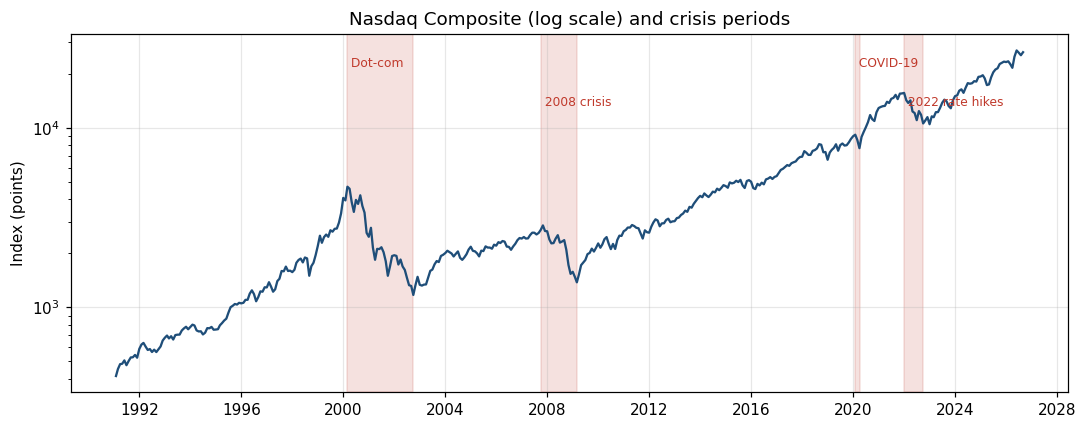

In [10]:
CRISES = [("2000-03", "2002-10", "Dot-com"), ("2007-10", "2009-03", "2008 crisis"),
          ("2020-02", "2020-04", "COVID-19"), ("2022-01", "2022-10", "2022 rate hikes")]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dataset.index, dataset["nasdaq"], color="#1f4e79")
ax.set_yscale("log")
top = ax.get_ylim()[1]
for i, (start, end, label) in enumerate(CRISES):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#c0392b", alpha=0.15)
    ax.text(pd.Timestamp(start), top * (0.75 if i % 2 == 0 else 0.45), " " + label,
            fontsize=8, color="#c0392b", va="top")
ax.set_title("Nasdaq Composite (log scale) and crisis periods")
ax.set_ylabel("Index (points)")
fig.tight_layout(); fig.savefig("figures/nasdaq_crises.pdf"); plt.show()

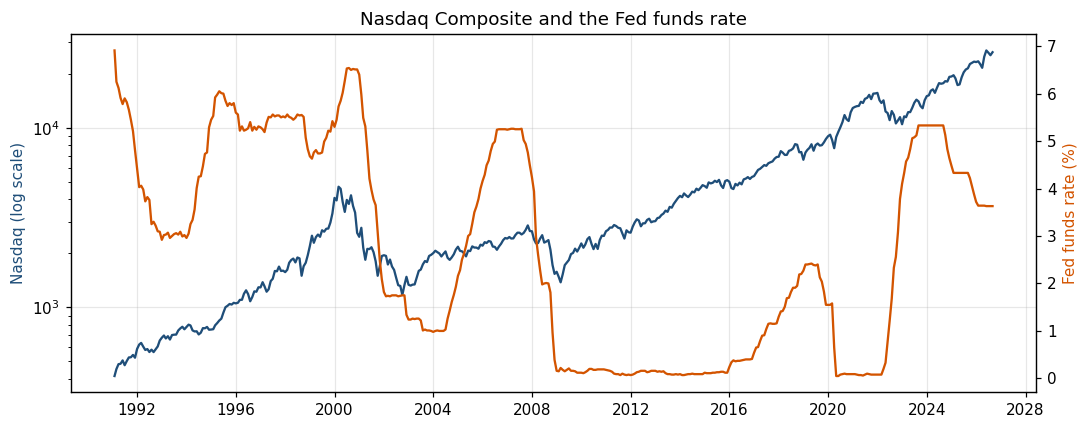

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(dataset.index, dataset["nasdaq"], color="#1f4e79", label="Nasdaq")
ax1.set_yscale("log"); ax1.set_ylabel("Nasdaq (log scale)", color="#1f4e79")
ax2 = ax1.twinx()
ax2.plot(dataset.index, dataset["fed_funds_rate"], color="#d35400", label="Fed funds rate")
ax2.set_ylabel("Fed funds rate (%)", color="#d35400"); ax2.grid(False)
ax1.set_title("Nasdaq Composite and the Fed funds rate")
fig.tight_layout(); fig.savefig("figures/nasdaq_fedfunds.pdf"); plt.show()

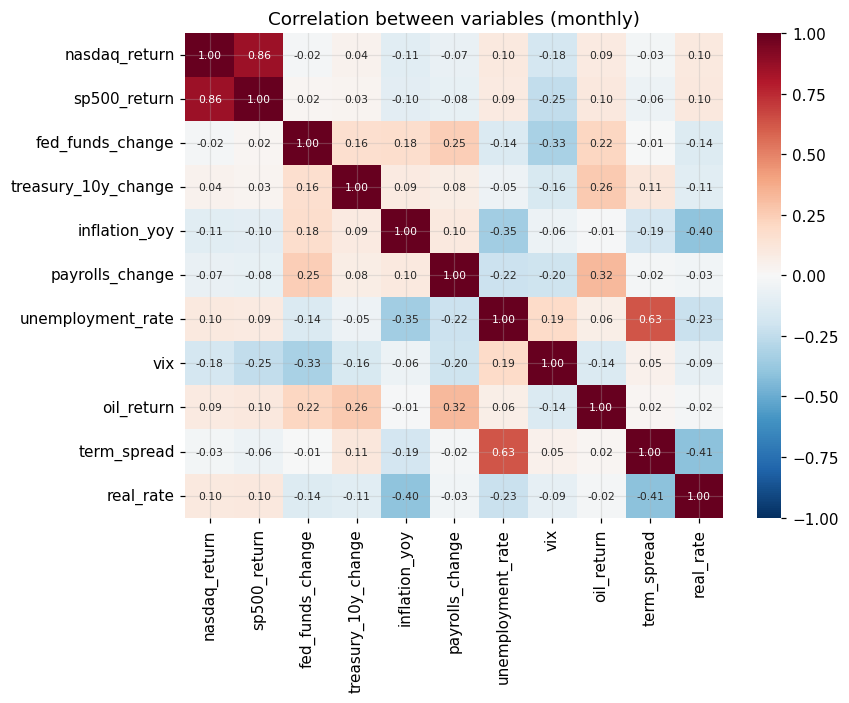

In [12]:
corr_cols = ["nasdaq_return", "sp500_return", "fed_funds_change", "treasury_10y_change",
             "inflation_yoy", "payrolls_change", "unemployment_rate", "vix", "oil_return",
             "term_spread", "real_rate"]
corr = dataset[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation between variables (monthly)")
fig.tight_layout(); fig.savefig("figures/correlation_heatmap.pdf"); plt.show()

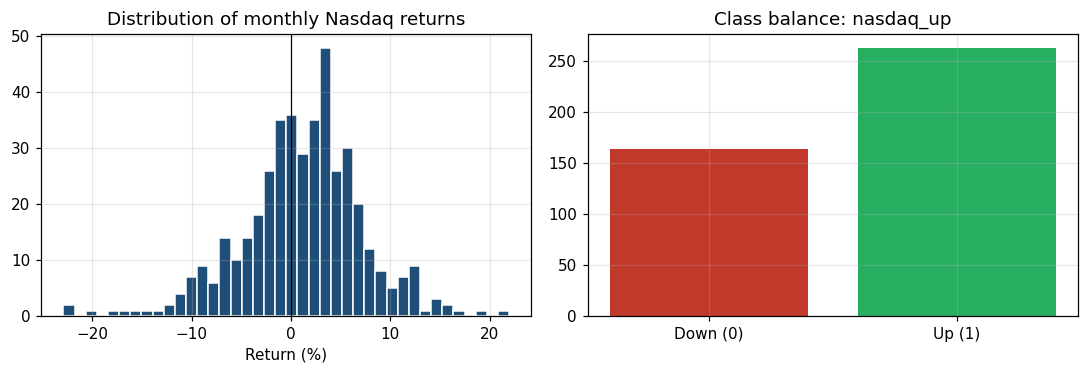

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(dataset["nasdaq_return"], bins=40, color="#1f4e79", edgecolor="white")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Distribution of monthly Nasdaq returns"); axes[0].set_xlabel("Return (%)")

counts = dataset["nasdaq_up"].value_counts().sort_index()
axes[1].bar(["Down (0)", "Up (1)"], counts.values, color=["#c0392b", "#27ae60"])
axes[1].set_title("Class balance: nasdaq_up")
fig.tight_layout(); fig.savefig("figures/return_distribution.pdf"); plt.show()

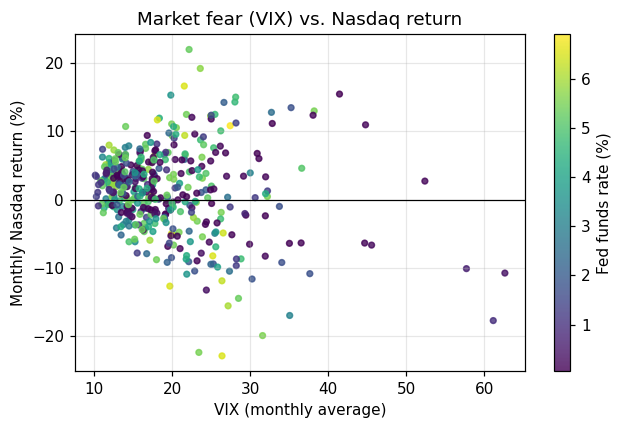

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(dataset["vix"], dataset["nasdaq_return"], c=dataset["fed_funds_rate"],
                cmap="viridis", s=14, alpha=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("VIX (monthly average)"); ax.set_ylabel("Monthly Nasdaq return (%)")
ax.set_title("Market fear (VIX) vs. Nasdaq return")
fig.colorbar(sc, label="Fed funds rate (%)")
fig.tight_layout(); fig.savefig("figures/vix_vs_return.pdf"); plt.show()

## 10. GitHub'a gönderme

Colab'da: **Dosya → GitHub'a kopya kaydet** ile notebook'u repoya kaydedin.
`data/` ve `figures/` klasörlerini indirmek için aşağıdaki hücreyi çalıştırıp zip'i repoya yükleyin
(veya repoyu Colab'a klonlayıp `git push` yapın).

In [15]:
!zip -qr outputs.zip data figures
from google.colab import files
files.download("outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Notlar (rapora yazılacaklar)
- **Yayın gecikmesi:** Aylık istihdam ve TÜFE verileri bir sonraki ayın başında açıklanır. Modelleme aşamasında bu sütunların bir ay gecikmeli (`shift(1)`) halleri kullanılmalı, yoksa gelecekteki bilgi modele sızar.
- **Revizyonlar:** FRED güncel (revize edilmiş) değerleri verir; o tarihte bilinen ilk değerler farklı olabilir.
- Veri çekim tarihi raporda belirtilmeli, çünkü seriler güncellendikçe son satırlar değişir.